In [1]:
import kagglehub as kh
from PIL import Image
import torch
import numpy as np
import typing as tt

import data_captcha
import models_captcha

In [2]:
images_path = data_captcha.get_images_path()
samples = data_captcha.get_samples(images_path)
train_samples, val_samples, test_samples = data_captcha.split_train_val_test(
    samples, data_captcha.TRAIN_TEST_DEFAULT_SEED, shuffle=True)

In [3]:
val_dataset = data_captcha.CaptchaDataset(val_samples)

In [4]:
model = models_captcha.CaptchaUNet()
model.eval()
device = torch.device("cpu")
weights = torch.load("models/04-captcha_best.model", map_location=device, weights_only=True)
model.load_state_dict(weights)

<All keys matched successfully>

In [5]:
def tensor_to_np(img_t: torch.Tensor) -> np.array:
    img_np = img_t.detach().numpy()
    out_np = (img_np.transpose((1, 2, 0)) * 255).astype(np.uint8)
    if out_np.shape[-1] == 1:
        out_np = out_np.repeat(3, axis=-1)
    return out_np

In [6]:
def apply_model(
    model: models_captcha.CaptchaUNet, 
    input_refs: tt.List[tt.Tuple[torch.Tensor]]
) -> Image:
    rows = []
    for input_t, (ref_t, _) in input_refs:
        out_t = model(input_t.unsqueeze(0))
        out_np = tensor_to_np(out_t[0])
        input_np = tensor_to_np(input_t)
        ref_np = tensor_to_np(ref_t)
        rows.append(np.hstack([ref_np, input_np, out_np]))
    res_np = np.vstack(rows)
    return Image.fromarray(res_np)

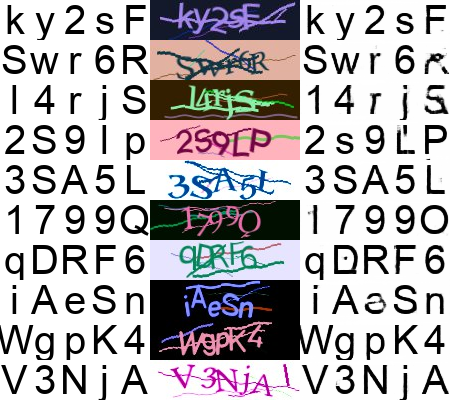

In [7]:
img = apply_model(model, [val_dataset[i] for i in range(10)])
img

In [8]:
img.save("captcha-unet-many.png")

In [9]:
val_samples[2]

(PosixPath('/Users/shmuma/.cache/kagglehub/datasets/parsasam/captcha-dataset/versions/1/l4rjS.jpg'),
 'l4rjS')

In [10]:
val_samples[3]

(PosixPath('/Users/shmuma/.cache/kagglehub/datasets/parsasam/captcha-dataset/versions/1/2S9lp.jpg'),
 '2S9lp')